In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [54]:
ac_df               = pd.read_csv("수정주가.csv", index_col = "Date", parse_dates = True)
mkt_cap             = pd.read_csv("mkt_cap.csv", index_col = "Date", parse_dates = True)
pbr                 = pd.read_csv("pbr.csv", index_col = "Date", parse_dates = True)
debt_short          = pd.read_csv("단기차입부채.csv", index_col = "Date", parse_dates = True)
debt_long           = pd.read_csv("장기차입부채.csv", index_col = "Date", parse_dates = True)
total_asset         = pd.read_csv("KOSPI_KOSDAQ_total_asset.csv", index_col = "Date", parse_dates = True)
issuance_equity     = pd.read_csv("equity issuance.csv", index_col = "Date", parse_dates = True)
cash_flow           = pd.read_csv("KOSPI_KOSDAQ_cash_flow.csv", index_col = 'Date', parse_dates = True)
sales               = pd.read_csv("sales.csv", index_col ='Date', parse_dates = True)

C:\Users\XH58\AppData\Local\Temp\ipykernel_115892\2794078793.py:5: DtypeWarning: Columns (3672) have mixed types. Specify dtype option on import or set low_memory=False.
  debt_long           = pd.read_csv("장기차입부채.csv", index_col = "Date", parse_dates = True)
C:\Users\XH58\AppData\Local\Temp\ipykernel_115892\2794078793.py:9: DtypeWarning: Columns (1687) have mixed types. Specify dtype option on import or set low_memory=False.
  sales               = pd.read_csv("sales.csv", index_col ='Date', parse_dates = True)


In [55]:
monthly_returns = ac_df.resample('ME').last().pct_change(fill_method = None)
monthly_mkt_cap = mkt_cap.resample('ME').last()
monthly_pbr = pbr.resample('ME').last()
monthly_debt_short = debt_short.resample('ME').last()               # lag 필요
monthly_debt_long = debt_long.resample('ME').last()                 # lag 필요
monthly_total_asset = total_asset.resample('ME').last()             # lag 필요
monthly_cash_flow = cash_flow.resample('ME').last()                 # lag 필요
monthly_issuance_equity = issuance_equity.resample('ME').last()
monthly_sales = sales.resample('ME').last()                         # lag 필요

# 연말(12월) 값으로 해당 연도의 모든 월말 데이터 fill
year_end_values = monthly_issuance_equity[monthly_issuance_equity.index.month == 12]
for year in year_end_values.index.year.unique():
    dec_date = year_end_values.index[year_end_values.index.year == year][0]
    monthly_issuance_equity.loc[monthly_issuance_equity.index.year == year] = year_end_values.loc[dec_date].values

In [56]:
# monthly_sales_numeric = monthly_sales.apply(pd.to_numeric, errors='coerce')
# monthly_mkt_cap_numeric = monthly_mkt_cap.apply(pd.to_numeric, errors='coerce')

In [57]:
monthly_debt_short = monthly_debt_short.shift(14)
monthly_debt_long = monthly_debt_long.shift(14)
monthly_total_asset = monthly_total_asset.shift(14)
monthly_cash_flow = monthly_cash_flow.shift(14)
monthly_sales = monthly_sales.shift(14)

In [58]:
monthly_sales_numeric = monthly_sales.apply(pd.to_numeric, errors='coerce')
monthly_mkt_cap_numeric = monthly_mkt_cap.apply(pd.to_numeric, errors='coerce')

In [59]:
# pbr이 0.2 이하이면 NaN으로 대체
monthly_pbr[monthly_pbr <= 0.2] = pd.NA

In [60]:
# 팩터 만들기 1. sales / mkt 2. external financing
sales_per_mkt = monthly_sales_numeric.div(monthly_mkt_cap_numeric, axis=0)
## sales 래그 하기 전에 팩터 만들면 nav 10 나와요. 래그 하고 팩터 만들면 73나와요
## 뭐가 맞는걸까요? 아무래도 래그하고가 맞겠죠...?

total_debt = monthly_debt_short + monthly_debt_long
equity_delta = monthly_cash_flow - monthly_issuance_equity # 현금흐름에서 주식발행을 뺐습니다
total_debt_delta = total_debt - total_debt.shift(12)
avg_assets = (monthly_total_asset + monthly_total_asset.shift(12)) / 2
factor = equity_delta / avg_assets + total_debt_delta / avg_assets

In [ ]:
# 윈저라이징: 팩터 2를 월별 크로스섹션 기준 상·하위 1%로 클리핑
factor_clean = factor.replace([np.inf, -np.inf], np.nan)
wins_threshold = 0.01
factor_w = factor_clean.clip(
    lower=factor_clean.quantile(wins_threshold, axis=1),
    upper=factor_clean.quantile(1 - wins_threshold, axis=1),
    axis=0
)
factor_m = factor_w  # 팩터는 이미 월말 기준

C:\Users\XH58\AppData\Local\Temp\ipykernel_115892\1984101713.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  factor_clean = factor.replace([np.inf, -np.inf], np.nan)


In [62]:
# 월별 리밸런싱: 월말 리스트 및 수익률
ret_m = monthly_returns
# 백테스트 기간, 월말 리스트
start_date = '2009-12-31'
end_date   = '2025-12-31'
month_ends = pd.date_range(start=start_date, end=end_date, freq='ME').tolist()
portfolio_combined = pd.Series(dtype=float)
stock_count_history = pd.Series(dtype=int) # 매월 몇 개 종목이 뽑히는지 저장

for i in range(len(month_ends) - 1):
    rebal_start = month_ends[i]
    rebal_end   = month_ends[i + 1]
    
    # 두 데이터가 해당 시점에 모두 있는지 확인
    if rebal_start not in sales_per_mkt.index or rebal_start not in factor_m.index:
        continue

    # 1. Sales/시총 상위 그룹 (예: 전체의 상위 30% 또는 상위 100개)
    # nlargest(20)으로 자르면 교집합이 너무 적을 수 있으니 범위를 좀 넓게 잡습니다. by gemini
    top_sales_pool = sales_per_mkt.loc[rebal_start].nlargest(100).index
    
    # 2. External Finance 2, 3, 4그룹 (우리가 아까 정한 알짜 그룹)
    f_t = factor_m.loc[rebal_start].dropna()
    if len(f_t) >= 10:
        deciles = pd.qcut(f_t, 10, labels=range(1, 11), duplicates='drop')
        finance_safe_pool = deciles[deciles.isin([2, 3, 4])].index
        
        # 3. ★ 핵심: 두 그룹의 교집합 찾기 ★
        final_selection = top_sales_pool.intersection(finance_safe_pool)
        
        # 종목 수 기록 (디버깅용)
        stock_count_history.loc[rebal_start] = len(final_selection)
        
        # 4. 수익률 계산
        if not final_selection.empty:
            r = ret_m.loc[rebal_end, ret_m.columns.intersection(final_selection)].dropna()
            portfolio_combined.loc[rebal_end] = r.mean() if not r.empty else np.nan

# 평균 몇 개의 종목으로 운용되는지 확인
print(f"평균 선정 종목 수: {stock_count_history.mean():.2f}개")

평균 선정 종목 수: 15.05개


In [63]:
# 포트폴리오 NAV (월 수익률 누적)
portfolio_nav = (1 + portfolio_combined.fillna(0)).cumprod()
portfolio_nav

2010-01-31     0.943074
2010-02-28     0.884402
2010-03-31     1.010313
2010-04-30     0.985051
2010-05-31     0.899507
                ...    
2025-08-31     9.524488
2025-09-30    10.287033
2025-10-31    10.030037
2025-11-30    10.232887
2025-12-31    10.435383
Length: 192, dtype: float64

<Axes: >

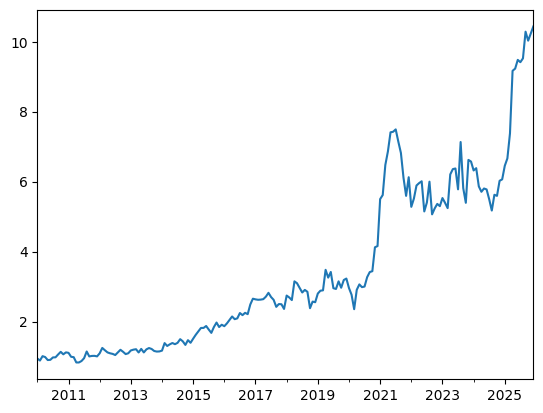

In [64]:
portfolio_nav.plot()

In [65]:
# CAGR 계산
years = (portfolio_nav.index[-1] - portfolio_nav.index[0]).days / 365.25
cagr  = portfolio_nav.iloc[-1] ** (1 / years) - 1
print(f'CAGR: {cagr:.2%}')

# 연 환산 변동성 계산
volatility = portfolio_combined.std() * np.sqrt(12)
print(f'Annualized Volatility: {volatility:.2%}')

# Sharpe Ratio 계산 (무위험 수익률 연 2% 반영)
risk_free_rate = (1 + 0.02) ** (1 / 12) - 1          
excess_returns = portfolio_combined - risk_free_rate
sharpe_ratio   = excess_returns.mean() / excess_returns.std() * np.sqrt(12)
print(f'Sharpe Ratio: {sharpe_ratio:.2f}')


CAGR: 15.88%
Annualized Volatility: 28.25%
Sharpe Ratio: 0.59
